In [8]:
from google.colab import files
uploaded = files.upload()

Saving S5P_NRTI_L2__NO2____20260316T072128_20260316T072628_43639_03_020901_20260316T080448.nc to S5P_NRTI_L2__NO2____20260316T072128_20260316T072628_43639_03_020901_20260316T080448 (1).nc


In [9]:
!pip install netCDF4 xarray

In [10]:
import xarray as xr


ds = xr.open_dataset("S5P_NRTI_L2__NO2____20260316T072128_20260316T072628_43639_03_020901_20260316T080448.nc", group = "PRODUCT")
print(ds)

<xarray.Dataset> Size: 29MB
Dimensions:                                               (time: 1,
                                                           scanline: 372,
                                                           ground_pixel: 450,
                                                           layer: 34,
                                                           vertices: 2,
                                                           corner: 4,
                                                           polynomial_exponents: 6,
                                                           intensity_offset_polynomial_exponents: 1)
Coordinates:
  * time                                                  (time) datetime64[ns] 8B ...
  * scanline                                              (scanline) float64 3kB ...
  * ground_pixel                                          (ground_pixel) float64 4kB ...
  * layer                                                 (layer) float64 272B ..

In [11]:
print(ds.sizes)

Frozen({'time': 1, 'scanline': 372, 'ground_pixel': 450, 'layer': 34, 'vertices': 2, 'corner': 4, 'polynomial_exponents': 6, 'intensity_offset_polynomial_exponents': 1})


In [12]:
from netCDF4 import Dataset

dataset = Dataset("S5P_NRTI_L2__NO2____20260316T072128_20260316T072628_43639_03_020901_20260316T080448.nc")
# print(dataset)
print(dataset.variables.keys())

dict_keys([])


In [13]:
print(ds.data_vars)

Data variables:
    delta_time                                            (time, scanline) datetime64[ns] 3kB ...
    time_utc                                              (time, scanline) object 3kB ...
    qa_value                                              (time, scanline, ground_pixel) float32 670kB ...
    nitrogendioxide_tropospheric_column                   (time, scanline, ground_pixel) float32 670kB ...
    nitrogendioxide_tropospheric_column_precision         (time, scanline, ground_pixel) float32 670kB ...
    nitrogendioxide_tropospheric_column_precision_kernel  (time, scanline, ground_pixel) float32 670kB ...
    averaging_kernel                                      (time, scanline, ground_pixel, layer) float32 23MB ...
    air_mass_factor_troposphere                           (time, scanline, ground_pixel) float32 670kB ...
    air_mass_factor_total                                 (time, scanline, ground_pixel) float32 670kB ...
    tm5_tropopause_layer_index           

In [15]:
no2 = ds['nitrogendioxide_tropospheric_column']
value = no2.isel(time=0, scanline=5, ground_pixel=10)
print(float(value))

1.6106252587633207e-05


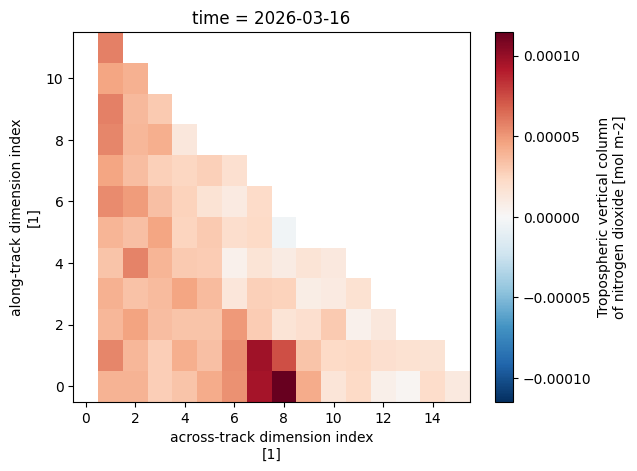

In [16]:
import numpy as np
import pandas as pd

# Define a simple bounding box (min_lat, max_lat, min_lon, max_lon)
# For a complex polygon, you would use geopandas and shapely.vectorized.contains
lat_min, lat_max = 10.0, 25.0
lon_min, lon_max = 70.0, 85.0

# Create a mask based on the coordinates in the dataset
mask = (
    (ds.latitude >= lat_min) & (ds.latitude <= lat_max) &
    (ds.longitude >= lon_min) & (ds.longitude <= lon_max)
)

# Apply mask and drop pixels outside the region
# Note: This returns a flattened or sparse representation depending on method
subset = ds.where(mask, drop=True)
display(subset.nitrogendioxide_tropospheric_column.plot())

In [17]:
import tensorflow as tf

layers = tf.keras.layers

# 1. Prepare Features (X) and Target (y)
# Usually, you convert the xarray to a pandas dataframe for ML
df = ds[['nitrogendioxide_tropospheric_column', 'qa_value', 'air_mass_factor_total']].to_dataframe().dropna()

# For prediction, you might use 'nitrogendioxide_tropospheric_column' as your target
# and other metadata/meteorology as features.
X = df[['air_mass_factor_total', 'qa_value']].values
y = df['nitrogendioxide_tropospheric_column'].values

# 2. Define a Simple Neural Network
model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Output for regression
])

model.compile(optimizer='adam', loss='mse')
print("Model summary for NO2 prediction:")
model.summary()

Model summary for NO2 prediction:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import numpy as np

# Check global attributes for resolution information
print("--- Global Attributes ---")
for attr in ['spatial_resolution', 'geospatial_lat_res', 'geospatial_lon_res']:
    if attr in ds.attrs:
        print(f"{attr}: {ds.attrs[attr]}")

# Calculate approximate resolution in km using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Sample points from the center of the dataset to avoid edge distortion
s, g = ds.scanline.size // 2, ds.ground_pixel.size // 2

lat_p1 = ds.latitude.isel(time=0, scanline=s, ground_pixel=g).values
lon_p1 = ds.longitude.isel(time=0, scanline=s, ground_pixel=g).values

# Across-track distance (ground pixels)
lat_p2 = ds.latitude.isel(time=0, scanline=s, ground_pixel=g+1).values
lon_p2 = ds.longitude.isel(time=0, scanline=s, ground_pixel=g+1).values
across_track = haversine(lat_p1, lon_p1, lat_p2, lon_p2)

# Along-track distance (scanlines)
lat_p3 = ds.latitude.isel(time=0, scanline=s+1, ground_pixel=g).values
lon_p3 = ds.longitude.isel(time=0, scanline=s+1, ground_pixel=g).values
along_track = haversine(lat_p1, lon_p1, lat_p3, lon_p3)

print(f"\nApproximate pixel size: {along_track:.2f} km (along-track) x {across_track:.2f} km (across-track)")
print(f"Approximate area per pixel: {along_track * across_track:.2f} km²")

--- Global Attributes ---

Approximate pixel size: 5.60 km (along-track) x 3.61 km (across-track)
Approximate area per pixel: 20.23 km²
